In [11]:
# %%
# =====================================
# Verified Synthetic Retraining (1-Round)
# Theoretical Loss vs Real-Data Theoretical Loss
# (X0 fixed; theory computed once per (a, γ); real-data loss constant)
# ====================================
import numpy as np
import math
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

import os
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

# --------------------------
# Truncated-normal helper functions
# --------------------------
def phi(x): 
    return 1.0 / np.sqrt(2*np.pi) * np.exp(-x**2 / 2)

def Phi(x): 
    return 0.5 * (1.0 + math.erf(x / np.sqrt(2)))

def C_func(a, b):
    # C(a,b) = (φ(b)-φ(a)) / (Φ(b)-Φ(a))
    denom = Phi(b) - Phi(a)
    return (phi(b) - phi(a)) / denom

def theta_func(a, b):
    r"""
    θ(a,b)
      = 1
        - [b φ(b) - a φ(a)] / [Φ(b) - Φ(a)]
        - { [φ(b) - φ(a)] / [Φ(b) - Φ(a)] }^2
    """
    denom = Phi(b) - Phi(a)
    return 1.0 - (b*phi(b) - a*phi(a))/denom - ((phi(b) - phi(a))/denom)**2

def lambda_func(a, b):
    r"""
    λ(a,b)
     = [ (b^2 - 1)φ(b) - (a^2 - 1)φ(a) ] / [ 2(Φ(b)-Φ(a)) ]
       + [ 3(φ(b)-φ(a)) * (bφ(b) - aφ(a)) ] / [ 2(Φ(b)-Φ(a))^2 ]
       + [ (φ(b)-φ(a))^3 ] / [ (Φ(b)-Φ(a))^3 ].
    """
    denom  = Phi(b) - Phi(a)
    denom2 = denom**2
    denom3 = denom**3
    part1 = ((b**2 - 1.0)*phi(b) - ((a**2) - 1.0)*phi(a)) / (2.0*denom)
    part2 = (3.0*(phi(b)-phi(a))*(b*phi(b) - a*phi(a))) / (2.0*denom2)
    part3 = ((phi(b)-phi(a))**3) / denom3
    return part1 + part2 + part3

# Map to theorem notation: m1 = -C, m2 = θ, m3 = λ
def m1_m2_m3(alpha, beta):
    m1 = -C_func(alpha, beta)
    m2 =  theta_func(alpha, beta)
    m3 = -2*lambda_func(alpha, beta)
    return m1, m2, m3

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def build_alpha_beta_per_direction(V, theta_star, theta_center, r, sigma, sigma_c=1):
    """
    alpha_j = (-r - sigma_c + v_j^T (theta_c - theta*)) / sigma
    beta_j  = ( r + sigma_c + v_j^T (theta_c - theta*)) / sigma
    """
    d = V.shape[1]
    delta = (theta_center - theta_star).reshape(-1)
    proj = V.T @ delta  # (d,)
    alpha = _safe_div(-r - sigma_c + proj, sigma)
    beta  = _safe_div( r + sigma_c + proj, sigma)
    return alpha, beta

# ---- Theorem 3.1 retraining theoretical loss ----
def theoretical_loss_per_direction(alpha_j, beta_j, sigma, n2, mu_j):
    """
    E[(θ̂_{1,proj,j} - v_j^T θ*)^2]
      ≈ σ^2 * [ m2/n2 + m1**2+( m2**2 + m3*m1)/μ_j^2 ]
    """
    m1, m2, m3 = m1_m2_m3(alpha_j, beta_j)
    return sigma**2 * ( m2 / n2 + m1**2 + ( m2**2 + m3*m1) / (mu_j**2) )

def theoretical_total_loss_from_X0(X0, theta_star, theta_center, r, sigma, sigma_c, n2):
    """
    Sum_j of the leading-order directional losses (Theorem 3.1).
    Returns (total, per_dir, (alpha, beta, mu, V))
    """
    n1, d = X0.shape
    U, s, Vt = np.linalg.svd(X0, full_matrices=False)  # s = μ_j, Vt = V^T
    V = Vt.T
    mu = s
    alpha, beta = build_alpha_beta_per_direction(
        V, theta_star[:d], theta_center[:d], r=r, sigma=sigma, sigma_c=sigma_c
    )
    per_dir = np.array([
        theoretical_loss_per_direction(alpha[j], beta[j], sigma, n2, mu[j])
        for j in range(d)
    ], dtype=float)
    total = float(np.sum(per_dir))
    return total, per_dir, (alpha, beta, mu, V)

# ---- Real-data theoretical loss (baseline): σ² ∑ μ_j^{-2} ----
def theoretical_real_loss_from_X0(X0, sigma):
    _, s, _ = np.linalg.svd(X0, full_matrices=False)
    mu = s
    return sigma**2 * np.sum(1.0 / (mu**2)), mu

# --------------------------
# Grid + single-theory evaluation per (a, γ), with FIXED X0
# --------------------------

def compute_entry_once(i, j, bias, width, X0, theta_star, sigma, global_u, n2):
    theta_center = theta_star + bias * (global_u / np.linalg.norm(global_u))
    theory_retrain_total, _, _ = theoretical_total_loss_from_X0(
        X0, theta_star, theta_center, r=width, sigma=sigma, sigma_c=sigma*np.sqrt(2/np.pi), n2=n2
    )
    return i, j, theory_retrain_total


## Set real data values

In [12]:
random_seed = 0
np.random.seed(random_seed)

n1 = 100
n2 = 100
sim_n = 100
d = 8
sigma = 1.0
n_bias = 300
n_width = 300

bias_vals  = np.linspace(0, 0.7, n_bias)      # a = ||θ* - θ_c||
width_vals = np.linspace(0.01, 0.5, n_width)   # γ = verifier width


# --- SINGLE GLOBAL RANDOM DIRECTION U (unit) FOR THE ENTIRE RUN ---
rng_dir = np.random.default_rng(random_seed + 777)  # deterministic from random_seed
u = rng_dir.normal(size=d)
u = u / np.linalg.norm(u)

print("direction vector u: ", u)

# --- FIXED GLOBAL X0 and its SVD directions V ---
rng_x0 = np.random.default_rng(random_seed + 12345)
X0 = rng_x0.normal(size=(n1, d))
# Precompute V from X0 (RIGHT singular vectors)
Vt = np.linalg.svd(X0, full_matrices=False)[2]  # shape (d, d)
V = Vt.T

theta_star = np.ones(d)


direction vector u:  [-0.32112345  0.02597075 -0.4739756  -0.60003962  0.23963805 -0.17795991
  0.44972197  0.14198192]


In [13]:


# Compute baseline once (constant across grid)

real_baseline_total, mu_fixed = theoretical_real_loss_from_X0(X0, sigma)

# Allocate arrays
theory_retrain_all = np.zeros((n_bias, n_width))
theory_real_all    = np.full((n_bias, n_width), real_baseline_total)  # constant matrix


# Evaluate grid (parallelized)
results = Parallel(n_jobs=-1)(
    delayed(compute_entry_once)(i, j, bias_vals[i], width_vals[j],
                                X0, theta_star, sigma, u, n2)
    for i in range(n_bias) for j in range(n_width)
)

for i, j, l_th_retrain in results:
    theory_retrain_all[i, j] = l_th_retrain

print("Done. (Fixed X0; real-data baseline constant across (a, γ).)")
print("Real-data baseline (scalar):", real_baseline_total)

Done. (Fixed X0; real-data baseline constant across (a, γ).)
Real-data baseline (scalar): 0.08373871826678209


Using data-driven colorbar range: [-0.800, 0.800]
[OK] Saved FIXED figure - no more white regions!


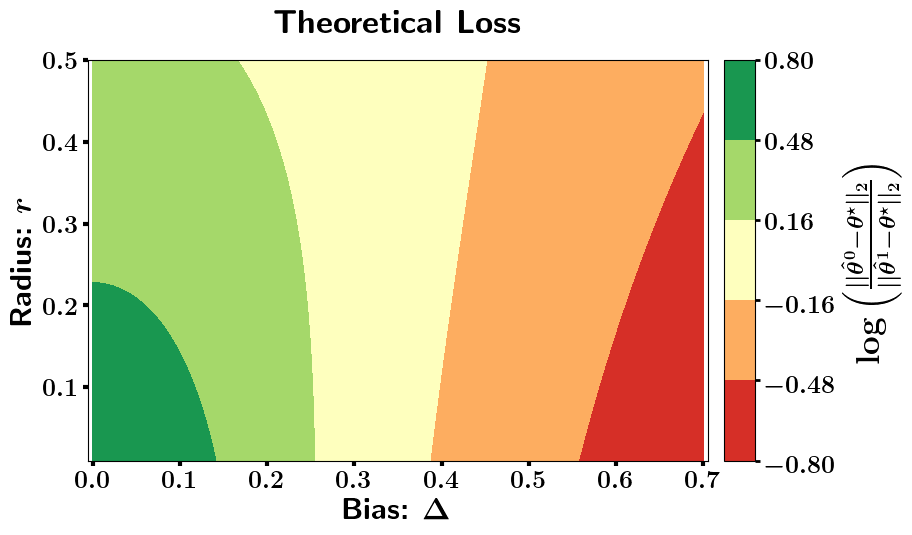

In [26]:
eps = 0
log_imp = 0.5*np.log((theory_real_all + eps) / (theory_retrain_all + eps)).T  # shape (n_width, n_bias)


# SOLUTION: Fixed version with proper colorbar range
# ============================================================
# Matplotlib styling (same as before)
# ============================================================
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2
plt.rcParams["text.latex.preamble"] = r"\usepackage{bm}\boldmath"

# ============================================================
# Color normalization and levels - FIXED RANGE
# ============================================================
# Use the actual data range instead of fixed [-1, 1.5]
# vmin, vmax = np.min(log_imp), np.max(log_imp)
vmin, vmax = -0.8, 0.8
levels = np.linspace(vmin, vmax, 6)  # More levels for smoother color transitions
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = 'RdYlGn'

print(f"Using data-driven colorbar range: [{vmin:.3f}, {vmax:.3f}]")

# ============================================================
# Figure: single plot + colorbar
# ============================================================
fig = plt.figure(figsize=(8.6, 5.2))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.05], wspace=0.05)
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

cf = ax.contourf(
    bias_vals, width_vals, log_imp,
    levels=levels, cmap=cmap, norm=norm
    # No extend parameter needed since we're using full data range
)

ax.set_xlim(bias_vals.min() - 0.005, bias_vals.max() + 0.005)
ax.set_ylim(width_vals.min(), width_vals.max())
ax.set_xlabel(r'\textbf{Bias:} $\mathbf{\Delta}$', fontsize=22, fontweight='bold')
ax.set_ylabel(r'\textbf{Radius:} $r$', fontsize=22, fontweight='bold')
ax.set_title(r'\textbf{Theoretical Loss}', fontsize=24, fontweight='bold', pad=20)

# ticks style
ax.tick_params(axis='both', labelsize=18, width=3)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(18)

# colorbar
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{||\hat{\theta}^0-\theta^{\star}||_2}{||\hat{\theta}^1-\theta^{\star}||_2} \right)}$',
    fontsize=24, fontweight='bold'
)
cbar.ax.tick_params(labelsize=18, width=2)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(18)

# ============================================================
# Save/show
# ============================================================
fig.savefig('fig_theoretical_loss_vs_real_loss_FIXED.png', bbox_inches='tight', dpi=600)
print(f"[OK] Saved FIXED figure - no more white regions!")
plt.show()


## Empirical

In [20]:
def simulate_one_round_per_direction(
    a, gamma, X0,  beta_star, V, n2=500, d=5, sigma=1.0,
    raw_batch_start=2000, raw_growth=2.0, max_batches=100,
    rng=None, direction_u=None
):
    """
    One Monte Carlo replicate with fixed design X0 (global) and SVD directions V:
      - y0 = X0 @ beta_star + eps0
      - beta0 = OLS(X0, y0)
      - Synthetic per-direction using mean v_j^T beta0 + noise
      - Three estimators:
          1) beta_real_only (no synthetic)
          2) beta_synth_filter (filter, per-direction kept exactly n2)
          3) beta_synth_nofilter (no filter, per-direction sample size n2)
      - Return their squared L2 losses relative to beta_star

    Verifier center: beta_prime = beta_star + a * u
      where u is a unit vector (here passed in as the single global direction).
    Threshold: |y - v_j^T beta_prime| <= gamma * ||v_j|| + sqrt(2/pi)*sigma
    """
    if rng is None:
        rng = np.random.default_rng()
    if direction_u is None:
        raise ValueError("direction_u must be provided as the global unit vector.")

    u = np.asarray(direction_u, dtype=float)
    u = u / np.linalg.norm(u)
    d = V.shape[0]  # ensure consistent dimensionality with X0/V
    beta_prime = beta_star[:d] + a * u

    # ----- real data -> beta0 (X0 is fixed; noise changes per replicate) -----
    n1 = X0.shape[0]
    eps0 = rng.normal(scale=sigma, size=n1)
    y0 = X0 @ beta_star[:d] + eps0
    beta0, *_ = np.linalg.lstsq(X0, y0, rcond=None)  # (d,)

    # ----- Estimator 1: real-only -----
    beta_real_only = beta0.copy()

    # ----- Estimator 2: per-direction synthetic with filtering (keep exactly n2 per direction) -----
    a_coords_fil = np.zeros(d, dtype=float)
    for j in range(d):
        vj = V[:, j]
        vj_norm = float(np.sqrt(vj @ vj))  # ~1
        center = float(vj @ beta_prime)
        mean_along = float(vj @ beta0)

        kept = []
        batch = int(max(1, raw_batch_start))
        batches_used = 0
        thresh = gamma * vj_norm + np.sqrt(2.0/np.pi) * sigma

        while len(kept) < n2:
            y_raw = mean_along + rng.normal(scale=sigma, size=batch)
            mask = np.abs(y_raw - center) <= thresh
            if np.any(mask):
                kept.extend(y_raw[mask].tolist())
            if len(kept) < n2:
                batch = int(np.ceil(batch * raw_growth))
                batches_used += 1
                if batches_used > max_batches:
                    a_coords_fil[j] = float(np.mean(kept)) if kept else mean_along
                    break

        if len(kept) >= n2:
            y_kept = np.array(kept[:n2], dtype=float)
            a_coords_fil[j] = float(np.mean(y_kept))

    beta_synth_filter = V @ a_coords_fil  # recombine

    # ----- Estimator 3: per-direction synthetic without filtering (exact n2 per direction) -----
    a_coords_nof = np.zeros(d, dtype=float)
    for j in range(d):
        vj = V[:, j]
        mean_along = float(vj @ beta0)
        y_raw = mean_along + rng.normal(scale=sigma, size=n2)
        a_coords_nof[j] = float(np.mean(y_raw))
    beta_synth_nofilter = V @ a_coords_nof

    # ----- losses -----
    loss_real_only      = float(np.linalg.norm(beta_real_only      - beta_star[:d])**2)
    loss_synth_filter   = float(np.linalg.norm(beta_synth_filter   - beta_star[:d])**2)
    loss_synth_nofilter = float(np.linalg.norm(beta_synth_nofilter - beta_star[:d])**2)

    return loss_real_only, loss_synth_filter, loss_synth_nofilter


# ----------------------------
# Monte Carlo average for a (bias), gamma (width), with fixed X0 and V
# ----------------------------
def compute_loss_entry(i, j, bias, width, X0, beta_star, V, n2, d, sigma, sim_n, seed_base, global_u):
    """
    Return averaged losses over sim_n replicates for (bias, width).
    Uses a SINGLE GLOBAL direction 'global_u' for the whole run:
      beta_prime = beta_star + bias * global_u
    Only three variants:
      0: real_only
      1: synth_filter
      2: synth_nofilter
    """
    if width <= 0:
        return i, j, np.nan, np.nan, np.nan, -1

    losses = np.zeros(3, dtype=float)  # [real_only, synth_filter, synth_nofilter]

    for t in range(sim_n):
        rng = np.random.default_rng(seed_base + 97*i + 131*j + 17*t)
        l0, l1, l2 = simulate_one_round_per_direction(
            a=bias, gamma=width, X0=X0,  beta_star=beta_star, V=V, n2=n2, d=d, sigma=sigma,
            raw_batch_start=2000, raw_growth=2.0, max_batches=100,
            rng=rng, direction_u=global_u
        )
        losses[0] += l0
        losses[1] += l1
        losses[2] += l2

    losses /= sim_n
    best_idx = int(np.nanargmin(losses))  # 0,1,2
    return i, j, losses[0], losses[1], losses[2], best_idx

### Empirical simulation

In [21]:

# --- Parameters (keep your style) ---


# --- Containers ---
which_min = np.full((n_bias, n_width), -1, dtype=int)
loss_real_only_all   = np.full((n_bias, n_width), np.nan)
loss_synth_fil_all   = np.full((n_bias, n_width), np.nan)
loss_synth_nofil_all = np.full((n_bias, n_width), np.nan)

# --- Parallel jobs ---
tasks = (
    delayed(compute_loss_entry)(
        i, j, bias_vals[i], width_vals[j],
        X0, theta_star, V, n2, d, sigma, sim_n, seed_base=random_seed, global_u=u
    )
    for i in range(n_bias) for j in range(n_width)
)

results = Parallel(n_jobs=-1)(
    task for task in tqdm(
        tasks, total=n_bias * n_width,
        desc="Simulating (one-round per-direction)", dynamic_ncols=True
    )
)

# --- Store results ---
for res in results:
    i, j, l_real, l_fil, l_nofil, idx = res
    loss_real_only_all[i, j]   = l_real
    loss_synth_fil_all[i, j]   = l_fil
    loss_synth_nofil_all[i, j] = l_nofil
    which_min[i, j] = idx


Simulating (one-round per-direction): 100%|██████████| 90000/90000 [08:38<00:00, 173.65it/s]


In [27]:
loss_real_only_all

array([[0.08457773, 0.07982424, 0.08910914, ..., 0.09358472, 0.08495867,
        0.08010546],
       [0.07995013, 0.08978416, 0.08866121, ..., 0.08437469, 0.08032038,
        0.08727213],
       [0.08889796, 0.08871636, 0.08272243, ..., 0.07953159, 0.08655502,
        0.07794805],
       ...,
       [0.08504467, 0.08613787, 0.07790461, ..., 0.08832262, 0.08589194,
        0.08464155],
       [0.08649309, 0.07724095, 0.08133612, ..., 0.08636839, 0.08539365,
        0.07776721],
       [0.077943  , 0.08428814, 0.08504104, ..., 0.08570284, 0.07698784,
        0.09133484]], shape=(300, 300))

Using data-driven colorbar range: [-0.800, 0.800]
[OK] Saved FIXED figure - no more white regions!


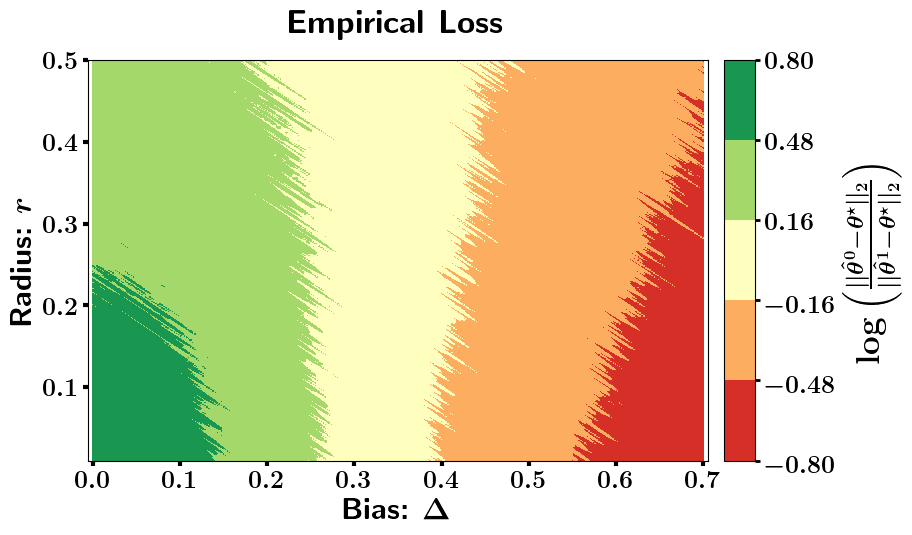

In [28]:
eps = 0
log_imp = 0.5*np.log((loss_real_only_all + eps) / (loss_synth_fil_all + eps)).T  # shape (n_width, n_bias)


# SOLUTION: Fixed version with proper colorbar range
# ============================================================
# Matplotlib styling (same as before)
# ============================================================
plt.rcParams["text.usetex"] = True
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.major.width"] = 1.2
plt.rcParams["ytick.major.width"] = 1.2
plt.rcParams["text.latex.preamble"] = r"\usepackage{bm}\boldmath"

# ============================================================
# Color normalization and levels - FIXED RANGE
# ============================================================
# Use the actual data range instead of fixed [-1, 1.5]
# vmin, vmax = np.min(log_imp), np.max(log_imp)
vmin, vmax = -0.8, 0.8
levels = np.linspace(vmin, vmax, 6)  # More levels for smoother color transitions
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = 'RdYlGn'

print(f"Using data-driven colorbar range: [{vmin:.3f}, {vmax:.3f}]")

# ============================================================
# Figure: single plot + colorbar
# ============================================================
fig = plt.figure(figsize=(8.6, 5.2))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.05], wspace=0.05)
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

cf = ax.contourf(
    bias_vals, width_vals, log_imp,
    levels=levels, cmap=cmap, norm=norm
    # No extend parameter needed since we're using full data range
)

ax.set_xlim(bias_vals.min() - 0.005, bias_vals.max() + 0.005)
ax.set_ylim(width_vals.min(), width_vals.max())
ax.set_xlabel(r'\textbf{Bias:} $\mathbf{\Delta}$', fontsize=22, fontweight='bold')
ax.set_ylabel(r'\textbf{Radius:} $r$', fontsize=22, fontweight='bold')
ax.set_title(r'\textbf{Empirical Loss}', fontsize=24, fontweight='bold', pad=20)

# ticks style
ax.tick_params(axis='both', labelsize=18, width=3)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(18)

# colorbar
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label(
    r'$\mathbf{\log \left( \frac{||\hat{\theta}^0-\theta^{\star}||_2}{||\hat{\theta}^1-\theta^{\star}||_2} \right)}$',
    fontsize=24, fontweight='bold'
)
cbar.ax.tick_params(labelsize=18, width=2)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(18)

# ============================================================
# Save/show
# ============================================================
fig.savefig('fig_empirical_loss_vs_real_loss.png', bbox_inches='tight', dpi=600)
print(f"[OK] Saved FIXED figure - no more white regions!")
plt.show()
